# Проект: Многоцелевая модель для NER + event-CLS

Этот Jupyter-ноутбук - пошаговый шаблон для выполнения проекта по объединённой (multi-task) модели, решающей **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

Модель должна решать параллельно две задачи: классифицировать токены на BIO-теги и классифицировать текст на принадлежность к 30 классам-характеристикам текста.

Характеристики:
```
['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']
```

Внимание: вам нужно реализовать весь рабочий код - в ноутбуке реализована только загрузка датасета. Все остальные ячейки служат как инструкции / места для вашего кода.


#### Структура ноутбука

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка данных, обзор, графики, выводы
3. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator
4. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
5. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
6. Инференс и анализ ошибок - реализовать inference pipeline и примеры



##### 1. EDA

Цели:

- Прочитать датасет.
- Посчитать встречаемость каждого класса в cls_vec.
- Построить графики: распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [238]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorForTokenClassification, AutoModel, AutoConfig, AutoTokenizer, get_linear_schedule_with_warmup
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import f1_score
from random import randrange
import time

dataset_name = 'danasone/nerel'
model_name = 'DeepPavlov/rubert-base-cased'
max_length = 512


In [239]:
ds = load_dataset(dataset_name, split='train', cache_dir='./cache')

In [240]:
cls_vectors = ds['cls_vec']
cls_array = np.array(cls_vectors)
class_counts = cls_array.sum(axis=0)

print(f"Ключи: {ds[0].keys()}")
print(f"Всего классов: {len(class_counts)}")
print(f"Всего документов: {len(cls_array)}")
print("\nВстречаемость каждого класса:")
for i, count in enumerate(class_counts):
    print(f"Класс {i}: {count} ({count/len(cls_array)*100:.2f}%)")

Ключи: dict_keys(['tokens', 'token_spans', 'tags', 'cls_vec', 'text'])
Всего классов: 30
Всего документов: 746

Встречаемость каждого класса:
Класс 0: 609 (81.64%)
Класс 1: 723 (96.92%)
Класс 2: 678 (90.88%)
Класс 3: 656 (87.94%)
Класс 4: 600 (80.43%)
Класс 5: 545 (73.06%)
Класс 6: 518 (69.44%)
Класс 7: 449 (60.19%)
Класс 8: 454 (60.86%)
Класс 9: 421 (56.43%)
Класс 10: 535 (71.72%)
Класс 11: 282 (37.80%)
Класс 12: 195 (26.14%)
Класс 13: 137 (18.36%)
Класс 14: 214 (28.69%)
Класс 15: 119 (15.95%)
Класс 16: 150 (20.11%)
Класс 17: 133 (17.83%)
Класс 18: 174 (23.32%)
Класс 19: 170 (22.79%)
Класс 20: 132 (17.69%)
Класс 21: 149 (19.97%)
Класс 22: 106 (14.21%)
Класс 23: 98 (13.14%)
Класс 24: 125 (16.76%)
Класс 25: 114 (15.28%)
Класс 26: 142 (19.03%)
Класс 27: 98 (13.14%)
Класс 28: 121 (16.22%)
Класс 29: 78 (10.46%)


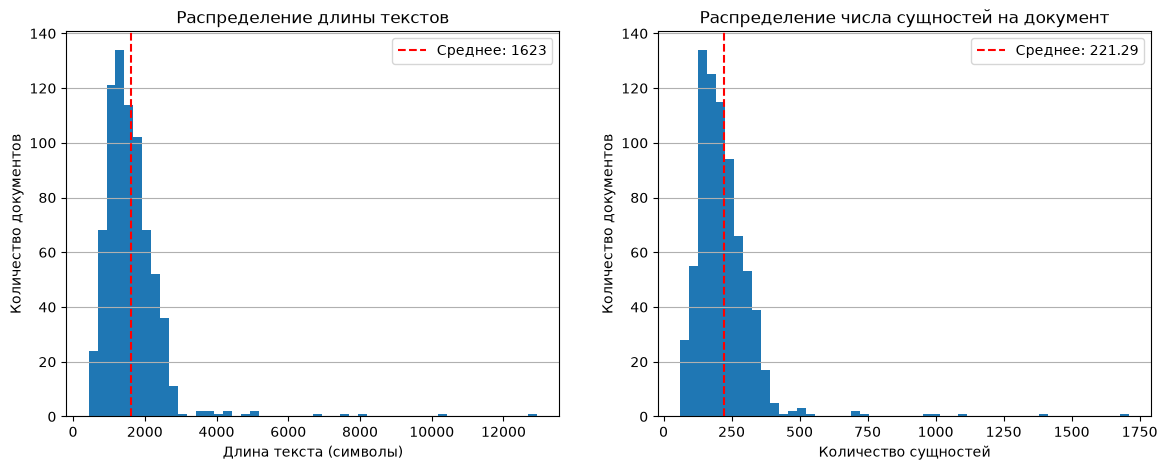

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_lengths = [len(text) for text in ds['text']]
axes[0].hist(text_lengths, bins=50)
axes[0].set_xlabel('Длина текста (символы)')
axes[0].set_ylabel('Количество документов')
axes[0].set_title('Распределение длины текстов')
axes[0].axvline(np.mean(text_lengths), color='red', linestyle='--', 
                label=f'Среднее: {np.mean(text_lengths):.0f}')
axes[0].legend()
axes[0].grid(axis='y')

num_entities = [len(spans) for spans in ds['token_spans']]
axes[1].hist(num_entities, bins=50)
axes[1].set_xlabel('Количество сущностей')
axes[1].set_ylabel('Количество документов')
axes[1].set_title('Распределение числа сущностей на документ')
axes[1].axvline(np.mean(num_entities), color='red', linestyle='--',
                label=f'Среднее: {np.mean(num_entities):.2f}')
axes[1].legend()
axes[1].grid(axis='y')

**Заключение**

Дисбаланс классов. 0-10 - превышают 50%, эти признаки встречаются чаще всего, Класс 1 - 96.92% - почти всегда присутствует. 11-29 от 10.46% до 37.8%, где количество положительных примеров мало. Для борьбы с ним будем использовать технику Uncertainty Weighting, как предложено на 4ом шаге шаблона.

Большие тексты. Среднее значение 1623 символа, мода на 2000 символах, но хвост уходит за отметку в 10к. Изначально, при проектировании использовал BERT/ROBERTA токенизатор, но он имеет оагрничение в 512 токенов -> почти все документы будут обрезаны. Это критично для задачи NER, так как важные сущности могут оказаться в конце текста. Нейронка посоветовала либо выставить ограничение в 256, либо использовать Sliding window коллатор. 

Но в результате эксперимента сокращения контекста с 512 до 256 получил следующие результаты:
NER: Микро-F1 упал на 1.6%, а марко - на 11%. CLS: микро - 8%, макро - 21%.

---

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



In [242]:
sample_index = randrange(len(cls_array))
# sample_index = 3
print(f"Индекс текста {sample_index}")

Индекс текста 348


In [243]:
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

In [244]:
raw_sample = ds[sample_index]
print(f"Текст: {raw_sample['text'][:200]}...\n")
print(f"Список слов (первые 15): {raw_sample['tokens'][:15]}")
print(f"BIO-теги слов (первые 15): {raw_sample['tags'][:15]}")
print(f"Спаны символов (первые 5): {raw_sample['token_spans'][:5]}")

print(f"Длина tokens: {len(raw_sample['tokens'])}, Длина tags: {len(raw_sample['tags'])}")

all_entity_types = set()
for doc_tags in ds['tags']:
    for tag in doc_tags:
        if tag != 'O':
            all_entity_types.add(tag.split('-')[1])

entity_classes = sorted(list(all_entity_types))
print(f"\nНайденные типы сущностей ({len(entity_classes)}): {entity_classes}")

label2id = {"O": 0}
current_id = 1
for ent_type in entity_classes:
    label2id[f"B-{ent_type}"] = current_id
    current_id += 1
    label2id[f"I-{ent_type}"] = current_id
    current_id += 1

print(f"Полный словарь меток ({len(label2id)} шт): {label2id}")

Текст: Мексика обыграла Германию на ЧМ-2018
Германия — Мексика
17 июня 2018 года на ЧМ-2018 сборная Мексики обыграла на Лужниках Германию со счётом 1:0.

Встречу посетило 78 011 зрителей, что является вторым...

Список слов (первые 15): ['Мексика', 'обыграла', 'Германию', 'на', 'ЧМ-2018', 'Германия', '—', 'Мексика', '17', 'июня', '2018', 'года', 'на', 'ЧМ-2018', 'сборная']
BIO-теги слов (первые 15): ['B-COUNTRY', 'O', 'B-COUNTRY', 'O', 'B-EVENT', 'B-COUNTRY', 'O', 'B-COUNTRY', 'B-DATE', 'I-DATE', 'I-DATE', 'O', 'O', 'B-EVENT', 'B-ORGANIZATION']
Спаны символов (первые 5): [[0, 7], [8, 16], [17, 25], [26, 28], [29, 36]]
Длина tokens: 260, Длина tags: 260

Найденные типы сущностей (29): ['AGE', 'AWARD', 'CITY', 'COUNTRY', 'CRIME', 'DATE', 'DISEASE', 'DISTRICT', 'EVENT', 'FACILITY', 'FAMILY', 'IDEOLOGY', 'LANGUAGE', 'LAW', 'LOCATION', 'MONEY', 'NATIONALITY', 'NUMBER', 'ORDINAL', 'ORGANIZATION', 'PENALTY', 'PERCENT', 'PERSON', 'PRODUCT', 'PROFESSION', 'RELIGION', 'STATE_OR_PROVINCE', 'TIME'

In [245]:
def tokenize_and_align_labels(examples, tokenizer, label2id, max_length):
    inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )

    labels = []
    for i in range(len(examples["tokens"])):
        word_ids = inputs.word_ids(batch_index=i)
        
        previous_word_idx = None
        label_ids = [-100] * len(inputs["input_ids"][i])
        
        for idx, word_idx in enumerate(word_ids):
            if word_idx is None:
                continue
            
            if word_idx != previous_word_idx:
                tag_str = examples["tags"][i][word_idx]
                label_ids[idx] = label2id.get(tag_str, label2id['O'])
            
            previous_word_idx = word_idx
            
        labels.append(label_ids)

    batch_output_dict = {k: v for k, v in inputs.items()}
    batch_output_dict["labels"] = np.array(labels, dtype=np.int64)
    batch_output_dict["cls_labels"] = np.array(examples["cls_vec"], dtype=np.float32)
    
    return batch_output_dict

In [246]:
columns_to_remove = [col for col in ds.column_names if col not in ['cls_vec']]
tokenized_ds = ds.map(
    lambda x: tokenize_and_align_labels(x, tokenizer, label2id, max_length),
    batched=True,
    remove_columns=columns_to_remove
)

In [247]:
sample = tokenized_ds[sample_index]
print("Проверка первого токенизированного примера:")
print(f"input_ids type: {type(sample['input_ids'])} | Длина: {len(sample['input_ids'])}")
print(f"attention_mask type: {type(sample['attention_mask'])} | Длина: {len(sample['attention_mask'])}")
print(f"labels type: {type(sample['labels'])} | Длина: {len(sample['labels'])}")
print(f"cls_labels type: {type(sample['cls_labels'])} | Размерность: {np.array(sample['cls_labels']).shape}")

all_labels_for_sample = sample['labels']

mask = [label_id != -100 for label_id in all_labels_for_sample]

decoded_tokens = tokenizer.convert_ids_to_tokens(sample['input_ids'])

first_tokens_filtered = []
first_ner_ids_filtered = []

for tok, lbl, keep in zip(decoded_tokens, all_labels_for_sample, mask):
    if keep and len(first_tokens_filtered) < 10:
        first_tokens_filtered.append(tok)
        first_ner_ids_filtered.append(lbl)

reversed_label2id = {v: k for k, v in label2id.items()}
first_ner_tags = [reversed_label2id[nid] for nid in first_ner_ids_filtered]

print(f"Пример первых реальных токенов: {first_tokens_filtered}")
print(f"Их NER-метки: {first_ner_tags}")

Проверка первого токенизированного примера:
input_ids type: <class 'list'> | Длина: 512
attention_mask type: <class 'list'> | Длина: 512
labels type: <class 'list'> | Длина: 512
cls_labels type: <class 'list'> | Размерность: (30,)
Пример первых реальных токенов: ['Мексика', 'обыграла', 'Германию', 'на', 'ЧМ', 'Германия', '—', 'Мексика', '17', 'июня']
Их NER-метки: ['B-COUNTRY', 'O', 'B-COUNTRY', 'O', 'B-EVENT', 'B-COUNTRY', 'O', 'B-COUNTRY', 'B-DATE', 'I-DATE']


In [248]:
class TorchNerelDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset.with_format("torch")
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids": item["input_ids"],
            "attention_mask": item["attention_mask"],
            "labels": item["labels"], 
            "cls_labels": item["cls_labels"]
        }

In [249]:
train_ds = TorchNerelDataset(tokenized_ds)
collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
train_dataloader = DataLoader(train_ds, 
                              batch_size=8, 
                              shuffle=True, 
                              collate_fn=collator, 
                              drop_last=False)

In [250]:
batch = next(iter(train_dataloader)) 
print("Состав батча:", list(batch.keys())) 
print("\nРазмеры:") 
for k, v in batch.items(): 
    print(f"{k}: {v.shape}")

Состав батча: ['input_ids', 'attention_mask', 'cls_labels', 'labels']

Размеры:
input_ids: torch.Size([8, 512])
attention_mask: torch.Size([8, 512])
cls_labels: torch.Size([8, 30])
labels: torch.Size([8, 512])


##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


In [251]:
class JointModel(nn.Module):
    def __init__(
        self, 
        config, 
        num_ner_labels: int = 59, 
        num_cls_labels: int = 30, 
        use_uncertainty_weight: bool = True
    ):
        super().__init__()
        
        self.config = config
        
        self.base_model = AutoModel.from_pretrained(config._name_or_path, config=config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.token_classifier = nn.Linear(config.hidden_size, num_ner_labels)
        
        self.cls_classifier = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size),
            nn.Tanh(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size, num_cls_labels)
        )
        
        self.use_uncertainty_weight = use_uncertainty_weight
        if self.use_uncertainty_weight:
            self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
            self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        cls_labels=None
    ):
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        sequence_output = outputs.last_hidden_state
        pooled_output = outputs.last_hidden_state[:, 0]

        sequence_output = self.dropout(sequence_output)
        pooled_output = self.dropout(pooled_output)

        token_logits = self.token_classifier(sequence_output)
        cls_logits = self.cls_classifier(pooled_output)

        loss = None
        if labels is not None and cls_labels is not None:
            
            token_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            reshaped_logits = token_logits.view(-1, self.token_classifier.out_features)
            reshaped_labels = labels.view(-1)
            token_loss = token_loss_fct(reshaped_logits, reshaped_labels)
            
            cls_loss_fct = nn.BCEWithLogitsLoss()
            cls_loss = cls_loss_fct(cls_logits, cls_labels.float())

            if self.use_uncertainty_weight:
                loss_token_term = torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
                loss_cls_term = torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
                loss = loss_token_term + loss_cls_term
            else:
                loss = token_loss + cls_loss

        return {
            "loss": loss,
            "logits": token_logits,
            "cls_logits": cls_logits
        }

In [252]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Используем: {device}")

Используем: cuda


In [253]:
num_ner_labels = len(label2id)
num_cls_labels = 30

config = AutoConfig.from_pretrained(model_name)
config.num_labels = num_ner_labels

joint_model = JointModel(config=config)
joint_model.to(device)

dummy_input_ids = torch.randint(0, 32000, (2, 512), device=device)
dummy_attention_mask = torch.ones((2, 512), dtype=torch.long, device=device)
dummy_labels = torch.randint(0, num_ner_labels, (2, 512), device=device)
dummy_labels[0, -10:] = -100
dummy_cls_labels = torch.randint(0, 2, (2, num_cls_labels), device=device).float()

output = joint_model(
    input_ids=dummy_input_ids,
    attention_mask=dummy_attention_mask,
    labels=dummy_labels,
    cls_labels=dummy_cls_labels
)

print(f"Итоговый Loss: {output['loss'].item():.4f}")
print(f"Токен-логиты: {output['logits'].shape}")
print(f"CLS-логиты: {output['cls_logits'].shape}")
print(f"log_sigma_token: {joint_model.log_sigma_token.item():.4f}")
print(f"log_sigma_cls: {joint_model.log_sigma_cls.item():.4f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33144.05it/s]
[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Итоговый Loss: 4.8907
Токен-логиты: torch.Size([2, 512, 59])
CLS-логиты: torch.Size([2, 30])
log_sigma_token: 0.0000
log_sigma_cls: 0.0000


##### 5. Training / Validation



In [254]:
optimizer = AdamW(joint_model.parameters(), lr=5e-5, weight_decay=0.01)

num_epochs = 5
total_steps = len(train_dataloader) * num_epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def compute_metrics(token_preds, token_labels, cls_preds, cls_labels):
    
    active_token_logits = token_preds.view(-1, joint_model.token_classifier.out_features)
    active_token_labels = token_labels.view(-1)
    
    predictions = torch.argmax(active_token_logits, dim=1).cpu().numpy()
    true_labels = active_token_labels.cpu().numpy()
    
    mask = true_labels != -100
    filtered_predictions = predictions[mask]
    filtered_true_labels = true_labels[mask]
    
    token_f1_macro = f1_score(filtered_true_labels, filtered_predictions, average='macro')
    token_f1_micro = f1_score(filtered_true_labels, filtered_predictions, average='micro')

    cls_probs = torch.sigmoid(cls_preds)
    cls_preds_binary = (cls_probs > 0.5).int().cpu().numpy()
    cls_labels_np = cls_labels.int().cpu().numpy()
    
    cls_f1_macro = f1_score(cls_labels_np, cls_preds_binary, average='macro', zero_division=0)
    cls_f1_micro = f1_score(cls_labels_np, cls_preds_binary, average='micro', zero_division=0)

    return {
        "token_f1_macro": token_f1_macro,
        "token_f1_micro": token_f1_micro,
        "cls_f1_macro": cls_f1_macro,
        "cls_f1_micro": cls_f1_micro
    }

In [255]:
device = torch.device(device)

joint_model.to(device)
best_val_loss = float('inf')
history = []

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    print(f"\n======== Эпоха {epoch + 1} / {num_epochs} ========")
    
    joint_model.train()
    train_loss = 0.0
    
    for step, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = joint_model(**batch)
        loss = outputs["loss"]
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(joint_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        train_loss += loss.item()
        
        if step % 50 == 0:
            print(f"Шаг {step}/{len(train_dataloader)} - Train Loss: {loss.item():.4f}")
            
    avg_train_loss = train_loss / len(train_dataloader)

    joint_model.eval()
    val_loss = 0.0
    all_token_preds, all_token_labels = [], []
    all_cls_preds, all_cls_labels = [], []

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        with torch.no_grad():
            outputs = joint_model(**batch)
            
        val_loss += outputs["loss"].item()
        
        all_token_preds.append(outputs["logits"].detach().cpu())
        all_token_labels.append(batch["labels"].detach().cpu())
        
        all_cls_preds.append(outputs["cls_logits"].detach().cpu())
        all_cls_labels.append(batch["cls_labels"].detach().cpu())

    avg_val_loss = val_loss / len(train_dataloader)
    
    concat_token_preds = torch.cat(all_token_preds)
    concat_token_labels = torch.cat(all_token_labels)
    concat_cls_preds = torch.cat(all_cls_preds)
    concat_cls_labels = torch.cat(all_cls_labels)
    
    metrics = compute_metrics(concat_token_preds, concat_token_labels, 
                              concat_cls_preds, concat_cls_labels)

    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        **metrics
    })

    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time

    hours, rem = divmod(epoch_duration, 3600)
    minutes, seconds = divmod(rem, 60)
    result_duration = f"{int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}"

    print(f"--- Результаты Эпохи {epoch + 1} ---")
    print(f"Loss -> Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")
    print(f"F1 Token -> Macro: {metrics['token_f1_macro']:.4f}, Micro: {metrics['token_f1_micro']:.4f}")
    print(f"F1 CLS   -> Macro: {metrics['cls_f1_macro']:.4f}, Micro: {metrics['cls_f1_micro']:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

    print(f"Время эпохи: {result_duration}")


======== Эпоха 1 / 5 ========
Шаг 0/94 - Train Loss: 4.7277
Шаг 50/94 - Train Loss: 1.3574
--- Результаты Эпохи 1 ---
Loss -> Train: 2.0631, Val: 0.9106
F1 Token -> Macro: 0.4007, Micro: 0.8867
F1 CLS   -> Macro: 0.3138, Micro: 0.7231
Время эпохи: 00:00:17

======== Эпоха 2 / 5 ========
Шаг 0/94 - Train Loss: 1.0110
Шаг 50/94 - Train Loss: 0.7048
--- Результаты Эпохи 2 ---
Loss -> Train: 0.8282, Val: 0.6442
F1 Token -> Macro: 0.6709, Micro: 0.9382
F1 CLS   -> Macro: 0.4272, Micro: 0.7562
Время эпохи: 00:00:17

======== Эпоха 3 / 5 ========
Шаг 0/94 - Train Loss: 0.7107
Шаг 50/94 - Train Loss: 0.5666
--- Результаты Эпохи 3 ---
Loss -> Train: 0.6396, Val: 0.5211
F1 Token -> Macro: 0.7485, Micro: 0.9628
F1 CLS   -> Macro: 0.4733, Micro: 0.7744
Время эпохи: 00:00:17

======== Эпоха 4 / 5 ========
Шаг 0/94 - Train Loss: 0.5644
Шаг 50/94 - Train Loss: 0.4626
--- Результаты Эпохи 4 ---
Loss -> Train: 0.5392, Val: 0.4623
F1 Token -> Macro: 0.8018, Micro: 0.9737
F1 CLS   -> Macro: 0.5066, Micr

**Результаты на локальном ПК - Индекс 3, контекст 512**
```
======== Эпоха 1 / 5 ========
Шаг 0/94 - Train Loss: 0.4992
Шаг 50/94 - Train Loss: 0.5125
--- Результаты Эпохи 1 ---
Loss -> Train: 0.4832, Val: 0.4070
F1 Token -> Macro: 0.8390, Micro: 0.9796
F1 CLS   -> Macro: 0.6183, Micro: 0.8198
Время эпохи: 00:00:17

======== Эпоха 2 / 5 ========
Шаг 0/94 - Train Loss: 0.4137
Шаг 50/94 - Train Loss: 0.4188
--- Результаты Эпохи 2 ---
Loss -> Train: 0.4291, Val: 0.3518
F1 Token -> Macro: 0.8778, Micro: 0.9858
F1 CLS   -> Macro: 0.6288, Micro: 0.8347
Время эпохи: 00:00:17

======== Эпоха 3 / 5 ========
Шаг 0/94 - Train Loss: 0.4033
Шаг 50/94 - Train Loss: 0.3801
--- Результаты Эпохи 3 ---
Loss -> Train: 0.3666, Val: 0.2961
F1 Token -> Macro: 0.9171, Micro: 0.9919
F1 CLS   -> Macro: 0.6904, Micro: 0.8558
Время эпохи: 00:00:17

======== Эпоха 4 / 5 ========
Шаг 0/94 - Train Loss: 0.3211
Шаг 50/94 - Train Loss: 0.3260
--- Результаты Эпохи 4 ---
Loss -> Train: 0.3228, Val: 0.2670
F1 Token -> Macro: 0.9266, Micro: 0.9943
F1 CLS   -> Macro: 0.7424, Micro: 0.8747
Время эпохи: 00:00:17

======== Эпоха 5 / 5 ========
Шаг 0/94 - Train Loss: 0.2658
Шаг 50/94 - Train Loss: 0.3071
--- Результаты Эпохи 5 ---
Loss -> Train: 0.2921, Val: 0.2568
F1 Token -> Macro: 0.9349, Micro: 0.9951
F1 CLS   -> Macro: 0.7488, Micro: 0.8792
Время эпохи: 00:00:17
```

Анализ логов обучения показывает, что модель обучается стабильно и эффективно. Несмотря на то что обучение длилось 5 эпох, основная часть «полезного» обучения завершилась раньше: Модель сходится быстро, к концу 3-ей эпохи val loss = 0.2961, после чего кривая валидации становится почти плоской (0.2670 -> 0.2568)


**Индекс 3, контекст 256**

```
======== Эпоха 1 / 5 ========
Шаг 0/94 - Train Loss: 4.8801
Шаг 50/94 - Train Loss: 1.5202
--- Результаты Эпохи 1 ---
Loss -> Train: 2.1253, Val: 0.9065
F1 Token -> Macro: 0.4174, Micro: 0.8907
F1 CLS   -> Macro: 0.3133, Micro: 0.7228
Время эпохи: 00:00:10

======== Эпоха 2 / 5 ========
Шаг 0/94 - Train Loss: 0.9248
Шаг 50/94 - Train Loss: 0.8466
--- Результаты Эпохи 2 ---
Loss -> Train: 0.8355, Val: 0.6518
F1 Token -> Macro: 0.6598, Micro: 0.9412
F1 CLS   -> Macro: 0.4020, Micro: 0.7521
Время эпохи: 00:00:09

======== Эпоха 3 / 5 ========
Шаг 0/94 - Train Loss: 0.6845
Шаг 50/94 - Train Loss: 0.6754
--- Результаты Эпохи 3 ---
Loss -> Train: 0.6448, Val: 0.5258
F1 Token -> Macro: 0.7698, Micro: 0.9645
F1 CLS   -> Macro: 0.4544, Micro: 0.7712
Время эпохи: 00:00:09

======== Эпоха 4 / 5 ========
Шаг 0/94 - Train Loss: 0.5060
Шаг 50/94 - Train Loss: 0.6031
--- Результаты Эпохи 4 ---
Loss -> Train: 0.5433, Val: 0.4601
F1 Token -> Macro: 0.8189, Micro: 0.9769
F1 CLS   -> Macro: 0.4802, Micro: 0.7815
Время эпохи: 00:00:10

======== Эпоха 5 / 5 ========
Шаг 0/94 - Train Loss: 0.5143
Шаг 50/94 - Train Loss: 0.5348
--- Результаты Эпохи 5 ---
Loss -> Train: 0.4890, Val: 0.4400
F1 Token -> Macro: 0.8296, Micro: 0.9792
F1 CLS   -> Macro: 0.5310, Micro: 0.7961
Время эпохи: 00:00:09
```


Задача NER (Token Classification)

| Параметр | max_length=512 | max_length=256 |
| -------- | -------------- | -------------- |
| F1 Micro | 0.9951         | 0.9792         |
| F1 Macro | 0.9349         | 0.8296         |

Задача Document Classification (CLS)

| Параметр | max_length=512 | max_length=256 |
| -------- | -------------- | -------------- |
| F1 Micro | 0.8792         | 0.7961         |
| F1 Macro | 0.7488         | 0.5310         |

---

##### 6. Инференс, квантизация и анализ ошибок

Проведите качественный анализ на 8–10 примерах: где NER ошибается? Какие типы сущностей плохо определяются? Насколько квантизация может ускорить инференс и сильно ли она ухудшает модель?



Текст: Иван Иванов, сотрудник Газпрома, полетел в Париж 15 мая 2023 года.
Предсказанные сущности:
- 'Иван Иванов,' (PERSON)
- 'сотрудник Газпрома,' (PROFESSION)
- 'полетел' (EVENT)
- 'Париж' (CITY)
- '15 мая 2023 года.' (DATE)


**Результат**

Текст: Иван Иванов, сотрудник Газпрома, полетел в Париж 15 мая 2023 года.

Итоговые сущности:
  - 'Иван Иванов,' (PERSON)
  - 'сотрудник Газпрома,' (PROFESSION)
  - 'полетел' (EVENT)
  - 'Париж' (CITY)
  - '15 мая 2023 года.' (DATE)

##### Заключение

Этот шаблон даёт вам чёткую дорожную карту и рабочие точки, где нужно реализовать код. В ноутбуке необходимо самостоятельно реализовать токенизацию/выравнивание меток, датасеты, модель, loss, тренировку и анализ.

Удачи - приступайте к реализации прямо в ноутбуке!